Installations

In [109]:
import pandas as pd
import pytz
import re
import unicodedata
import nltk
import json
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize
nltk.download('stopwords')
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.sparse import csr_matrix

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\fatim\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\fatim\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\fatim\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


commnets

In [110]:
comments = pd.read_csv('instagram_comments.csv')
data = comments.loc[:,['post_id','created_at','username','text','parent_comment_id']]

Drop empty comments
Remove comments from pdamsuryasembada
Change date from epoch miliseconds
Remove taggings from comments

In [111]:
data = data[data['username'].str.contains('pdamsuryasembada') == False]

data = data.drop_duplicates(subset=['text'])

local_timezone = pytz.timezone('Asia/Jakarta')
data['created_at'] = pd.to_datetime(data['created_at'], unit='s')
data['created_at'] = data['created_at'].dt.tz_localize('UTC').dt.tz_convert(local_timezone)
data['created_at'] = data['created_at'].dt.strftime('%Y-%m-%d %H:%M:%S %Z')

def remove_tags(text):
    if not isinstance(text, str):
        return ""
    return re.sub(r'@\w[\w\.]*', '', text).strip()

data['text'] = data['text'].apply(remove_tags)

data = data.dropna(subset=["text"])
data = data[data["text"].astype(str).str.strip() != ""]

cleaning

In [112]:
PUNCT_TO_REMOVE = "!#$%&()*+,./:;<=>@[\\]^_{|}~`"
def remove_punctuation(text):
    """custom function to remove the punctuation"""
    return text.translate(str.maketrans('', '', PUNCT_TO_REMOVE))

data["text"] = data["text"].apply(lambda text: remove_punctuation(text))

def remove_emojis(text):
    """Removes standard unicode emojis from the text."""
    if not isinstance(text, str):
        return text

    emoji_pattern = re.compile(
        "["                     
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
        u"\U0001F700-\U0001F77F"
        u"\U0001F780-\U0001F7FF"
        u"\U0001F800-\U0001F8FF"
        u"\U0001F900-\U0001F9FF"
        u"\U0001FA70-\U0001FAFF"
        u"\u2600-\u26FF"
        u"\u2700-\u27BF"
        u"\ufe0f"
        "]+",
        flags=re.UNICODE,
    )

    return emoji_pattern.sub(r'', text)

data['text'] = data['text'].apply(remove_emojis)
data['text'] = data['text'].str.strip()

def normalize_fancy_unicode(text):
    if not isinstance(text, str):
        return text

    normalized = unicodedata.normalize("NFKD", text)

    cleaned = "".join(
        ch for ch in normalized
        if not unicodedata.combining(ch)
    )
    return cleaned

data["text"] = data["text"].apply(normalize_fancy_unicode)

data = data.dropna(subset=["text"])
data = data[data["text"].astype(str).str.strip() != ""]

case folding

In [113]:
data["text"] = data["text"].str.lower()

tokem

In [114]:
data['text'] = data['text'].astype(str).apply(word_tokenize)

In [115]:
def is_all_numbers(tokens):
    return all(re.fullmatch(r'\d+', tok) for tok in tokens)

data = data[~data['text'].apply(is_all_numbers)]


def normalize_mixed_number_token(token):
    if re.fullmatch(r'\d+', token):
        return "<num>"
    
    parts = re.findall(r'\d+|[a-zA-Z]+', token)

    if len(parts) == 1:
        return token

    parts = ["<num>" if p.isdigit() else p for p in parts]

    return " ".join(parts)


def normalize_tokens(token_list):
    normalized = []
    for tok in token_list:
        if tok.isdigit():
            normalized.append("<num>")
        elif re.search(r'\d', tok):
            normalized.append(normalize_mixed_number_token(tok))
        else:
            normalized.append(tok)
    return normalized

data["text"] = data["text"].apply(normalize_tokens)

In [120]:
data_partial = data.copy()
# # data_partial.to_csv('partial_no_pdam4.csv', index=False)
# data_oct = data[(data['created_at'] > '2025-10-01') & (data['created_at'] < '2025-11-01')]
# data_sept = data[(data['created_at'] > '2025-09-01') & (data['created_at'] < '2025-10-01')]
# # data_sept.to_csv('september_comments.csv', index=False)
# data_partial = data_oct.copy()


# the partial thing will be done after stemming, for preparation of demo

formalize

In [121]:
with open("dictionary/dict_template3_doneig.json", "r", encoding="utf-8") as f:
    formal_dict = json.load(f)
def apply_formalization(tokens, formal_dict):
    new_tokens = []
    for tok in tokens:
        if tok in formal_dict:
            new_tokens.append(formal_dict[tok])
        else:
            new_tokens.append(tok)
    return new_tokens

data_partial["text"] = data_partial["text"].apply(lambda tokens: apply_formalization(tokens, formal_dict))

deletus stopwordus

In [122]:
with open('stopwords2.txt', 'r', encoding='utf-8') as f:
    custom_stopwords = set([line.strip() for line in f if line.strip()])

def remove_stopwords(tokens, stopword_set):
    return [tok for tok in tokens if tok not in stopword_set and tok.strip() != ""]

data_partial["text"] = data_partial["text"].apply(lambda tokens: remove_stopwords(tokens, custom_stopwords))

stemmming

In [ ]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()
def stem_tokens(tokens):
    return [stemmer.stem(tok) for tok in tokens]
data_partial["text"] = data_partial["text"].apply(stem_tokens)


In [124]:
data_partial.to_csv("stemmed_all.csv", index=False)

In [125]:
data_partial = data_partial[(data_partial['created_at'] > '2025-10-01') & (data['created_at'] < '2025-11-01')]
data_partial

,post_id,created_at,username,text,parent_comment_id
22,DPiRgn6k9BI,2025-10-29 23:44:51 WIB,n_aiiniiii,"[maaf, gak, paham, min, harga, pasang, pdam, min]",NaN
23,DPiRgn6k9BI,2025-10-30 05:38:39 WIB,raymundus_aryo,"[rame, nih, kdm, min]",NaN
27,DPiRgn6k9BI,2025-10-31 04:47:10 WIB,opera8176,"[min, pdam, jalan, gresik, mati, gimana]",NaN
29,DPiRgn6k9BI,2025-10-31 10:05:24 WIB,matokebenny,"[tugas, wilayah, ploso, timur, tolong, sp, kal...",NaN
30,DPiRgn6k9BI,2025-10-31 10:06:07 WIB,matokebenny,"[kali, kirim, komplain, langsung, pecat, tugas]",NaN
...,...,...,...,...,...
17263,C8jD4uDP9Bt,2025-10-16 01:37:13 WIB,mamaerisma30,"[pdampdamtolong, bikin, hidup, susahmasak, beg...",NaN
17265,C8jD4uDP9Bt,2025-10-23 06:20:37 WIB,babyjotuhumena,"[pdam, hebat, kl, lambat, bayar, cepat num, pu...",NaN
17267,C8jD4uDP9Bt,2025-10-25 14:55:57 WIB,melongrus,"[wilayah, dilendang, beso, kemaren, nyala, mat...",NaN
17269,C8jD4uDP9Bt,2025-10-30 14:25:29 WIB,moh.asyari3112,"[wilayah, lampung, adu, nga, ya]",NaN


tfidf ig

In [126]:
from sklearn.feature_extraction.text import TfidfVectorizer
data_partial['processed_text'] = data_partial['text'].apply(lambda tokens: " ".join(tokens))
data_partial = data_partial[data_partial['processed_text'].str.strip() != ""]
vectorizer = TfidfVectorizer(
    tokenizer=str.split,
    ngram_range=(1,1),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

vectors = vectorizer.fit_transform(data_partial['processed_text'])
feature_names = vectorizer.get_feature_names_out()
vectors_dense = vectors.toarray()

d:\Kuliah\PA\pdam-scraper\scrape_instagram\venv\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [127]:
print(f"Vector shape: {vectors.shape}")
print(f"nonzero: {vectors.nnz}")
row = vectors[13]
indices = row.indices
values = row.data

for i, v in zip(indices, values):
    print(feature_names[i], v) 

Vector shape: (1159, 713)
nonzero: 7256
mati 0.322601526555081
air 0.2829192632302973
rungkut 0.9032634973016219


Grounding TF-IDF

In [ ]:
max_values_per_document = np.max(vectors_dense, axis=1)
thresholds = 0.5 * max_values_per_document
thresholds_reshaped = thresholds.reshape(-1, 1)
vectors_grounded = np.where(vectors_dense < thresholds_reshaped, 0, vectors_dense)
vectors_grounded_sparse = csr_matrix(vectors_grounded)

# output_filename = 'grounded_tfidf_matrix_dense.npy'
# np.save(output_filename, vectors_grounded)
# print(f"Dense matrix saved to {output_filename}")

(1159, 713)

Linkage shape: (1158, 4), Samples: 1159
max_k 100

Optimal K Results:
• WCSS Curvature: 95
• Silhouette Max: 2


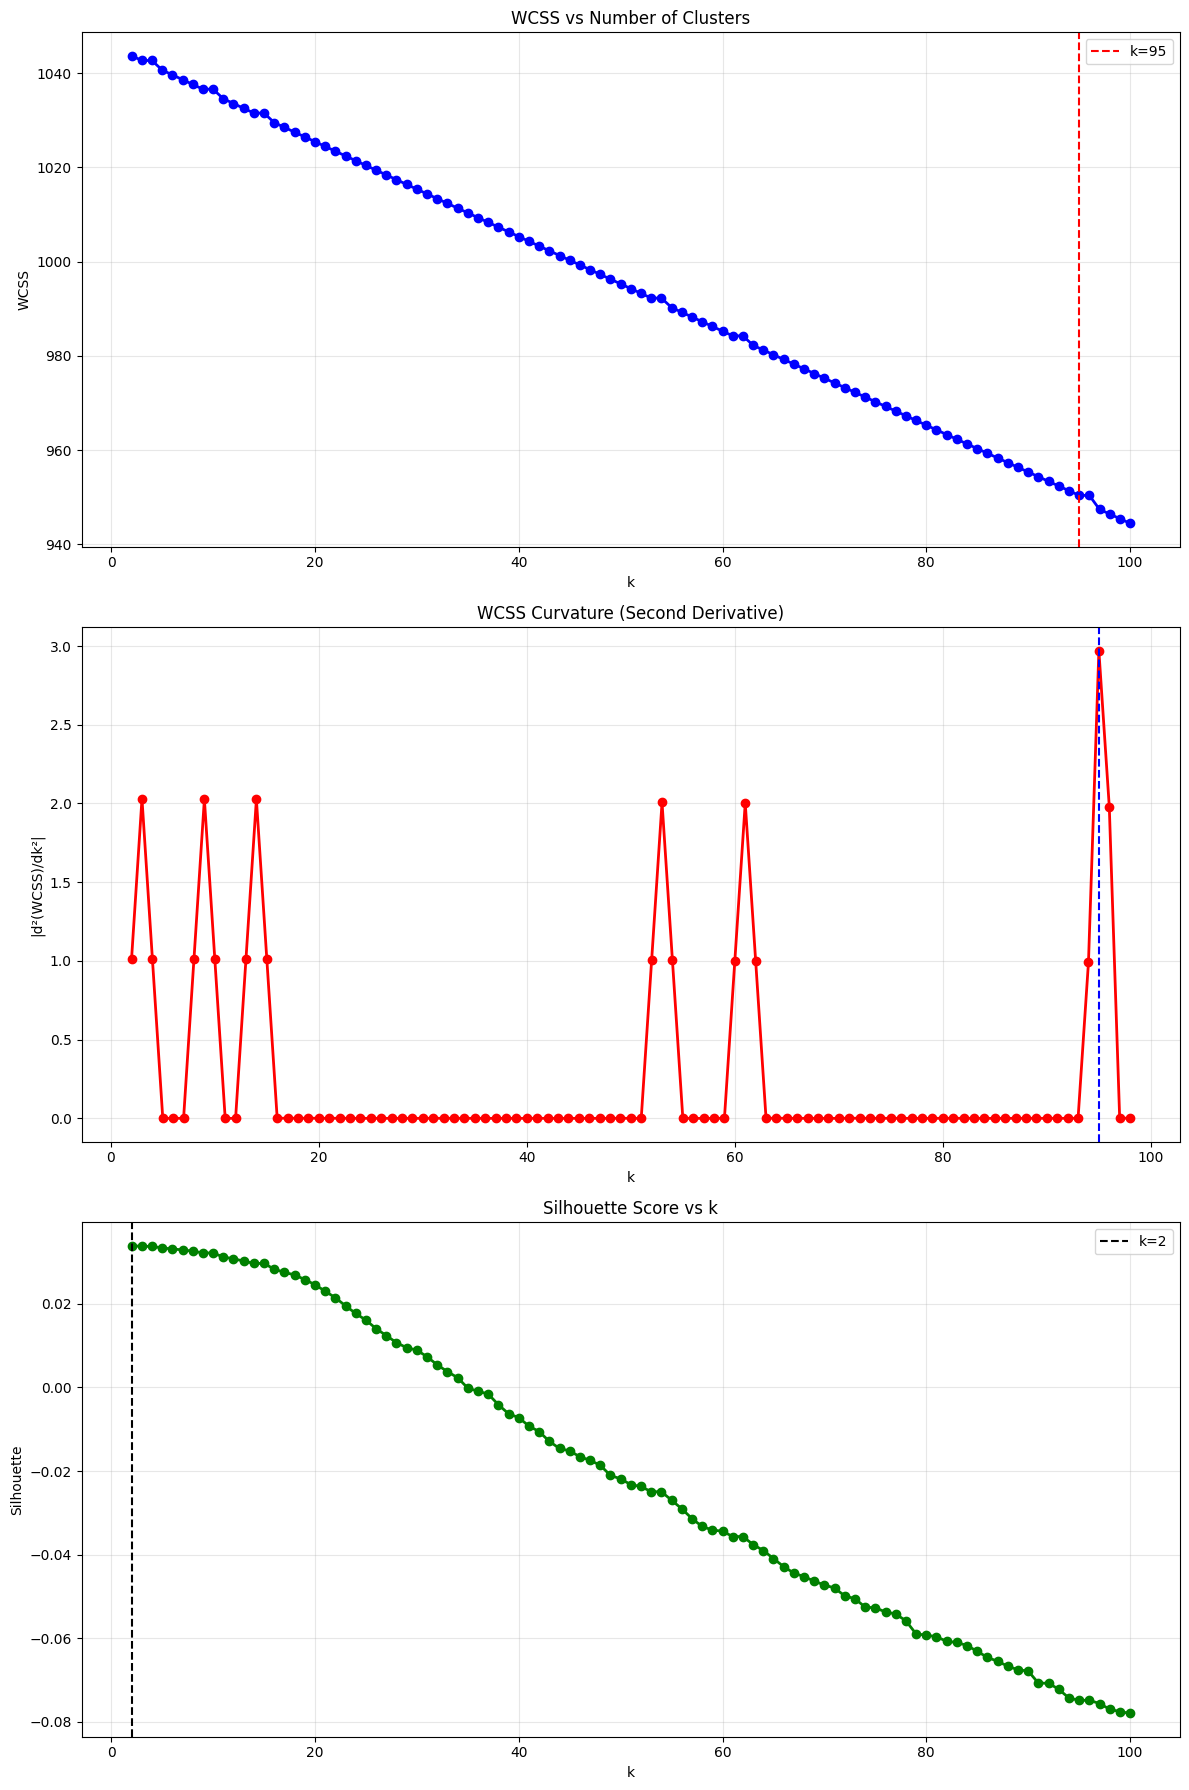

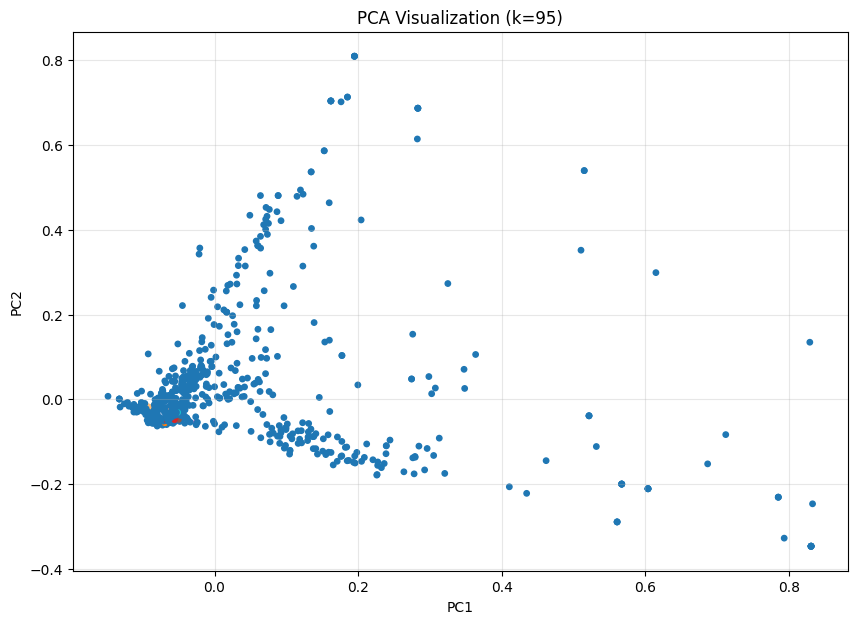

In [129]:
Z = linkage(vectors_dense, method='centroid', metric='euclidean')
Z_grounded = linkage(vectors_grounded, method='centroid', metric='euclidean')
n_samples = vectors_dense.shape[0]
print(f"Linkage shape: {Z.shape}, Samples: {n_samples}")

MIN_SAMPLES_PER_CLUSTER = 20
max_k = 100#min(n_samples // MIN_SAMPLES_PER_CLUSTER, n_samples)
print("max_k", max_k)
k_list = list(range(max_k, 1, -1))

wcss, sil = [], []

for k in k_list:
    # labels = fcluster(Z, t=k, criterion='maxclust')
    labels = fcluster(Z_grounded, t=k, criterion='maxclust')
    
    # Wcss
    total_var = 0.0
    for cid in np.unique(labels):
        # pts = vectors_dense[labels == cid]
        pts = vectors_grounded[labels == cid]
        if pts.shape[0] <= 1:
            continue
        cent = pts.mean(axis=0)
        total_var += np.sum(np.linalg.norm(pts - cent, axis=1)**2)
    wcss.append(total_var)
    
    # Sil
    if len(np.unique(labels)) >= 2:
        # sc = silhouette_score(vectors_dense, labels, metric='euclidean')
        sc = silhouette_score(vectors_grounded, labels, metric='euclidean')
    else:
        sc = np.nan
    sil.append(sc)

wcss, sil = np.array(wcss), np.array(sil)

# cobacob dl
# WCSS Curve
first = np.diff(wcss)
second = np.diff(first)
idx_curv = np.nanargmax(np.abs(second))
k_curv = k_list[idx_curv + 2]

# Silhouette Max
valid_idx = np.where(~np.isnan(sil))[0]
k_sil = k_list[valid_idx[np.nanargmax(sil[valid_idx])]] if len(valid_idx) else None

print(f"\nOptimal K Results:")
print(f"• WCSS Curvature: {k_curv}")
print(f"• Silhouette Max: {k_sil}")


fig, axes = plt.subplots(3, 1, figsize=(12, 18))
# Within cluster sum of squaress plt
axes[0].plot(k_list, wcss, 'bo-', linewidth=2)
axes[0].axvline(k_curv, color='red', linestyle='--', label=f"k={k_curv}")
axes[0].set_title("WCSS vs Number of Clusters")
axes[0].set_xlabel("k"); axes[0].set_ylabel("WCSS")
axes[0].grid(alpha=0.3); axes[0].legend()

# Curve plt
axes[1].plot(k_list[2:], np.abs(second), 'ro-', linewidth=2)
axes[1].axvline(k_curv, color='blue', linestyle='--')
axes[1].set_title("WCSS Curvature (Second Derivative)")
axes[1].set_xlabel("k"); axes[1].set_ylabel("|d²(WCSS)/dk²|")
axes[1].grid(alpha=0.3)

# # Silhouette plt
axes[2].plot(k_list, sil, 'go-', linewidth=2)
if k_sil:
    axes[2].axvline(k_sil, color='black', linestyle='--', label=f"k={k_sil}")
axes[2].set_title("Silhouette Score vs k")
axes[2].set_xlabel("k"); axes[2].set_ylabel("Silhouette")
axes[2].grid(alpha=0.3); axes[2].legend()

plt.tight_layout()
plt.show()

# PCA Vis
k_optimal = k_curv
labels_opt = fcluster(Z_grounded, t=k_optimal, criterion='maxclust')
# labels_opt = fcluster(Z, t=k_optimal, criterion='maxclust')

pca = PCA(n_components=2)
# vec2d = pca.fit_transform(vectors_dense)
vec2d = pca.fit_transform(vectors_grounded)

plt.figure(figsize=(10, 7))
plt.scatter(vec2d[:,0], vec2d[:,1], c=labels_opt, cmap='tab20', s=15)
plt.title(f"PCA Visualization (k={k_optimal})")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.grid(alpha=0.3)
plt.show()

In [130]:
def simple_keyword(tfidf_matrix, feature_names, labels, k):
    cluster_keywords = {}
    
    for cluster_id in range(1, k + 1):
        indices = np.where(labels == cluster_id)[0]
        
        if len(indices) == 0:
            cluster_keywords[cluster_id] = []
            continue

        cluster_data = tfidf_matrix[indices]

        if hasattr(cluster_data, 'toarray'):
            cluster_data = cluster_data.toarray()

        cluster_mean = cluster_data.mean(axis=0)
        threshold = cluster_mean.max() / 2
        above_threshold = np.where(cluster_mean > threshold)[0]
        sorted_idx = above_threshold[np.argsort(-cluster_mean[above_threshold])]
        
        keywords = [(feature_names[i], cluster_mean[i]) for i in sorted_idx]
        cluster_keywords[cluster_id] = keywords
    
    return cluster_keywords

keywords = simple_keyword(vectors_dense, feature_names, labels_opt, k_optimal)

for cluster_id in range(1, min(k_optimal + 1, n_samples)):
    if cluster_id in keywords and keywords[cluster_id]:
        print(f"\nCluster {cluster_id}:")
        for word, score in keywords[cluster_id][:10]:
            print(f"  {word}: {score:.3f}")


Cluster 1:
  wahh: 1.000

Cluster 2:
  air: 0.090
  mati: 0.087
  min: 0.066
  nyala: 0.058

Cluster 3:
  balas: 0.687
  dm: 0.601
  ga: 0.409

Cluster 4:
  tau: 0.558
  kalo: 0.499
  barat: 0.490
  benowo: 0.447

Cluster 5:
  promo: 0.657
  sampek: 0.488
  tanggal: 0.430
  info: 0.382

Cluster 6:
  diskon: 0.397
  ben: 0.381
  bingung: 0.358
  rugi: 0.349
  seng: 0.335
  g: 0.292
  tagih: 0.279
  warga: 0.259
  banyu: 0.239
  kerja: 0.220

Cluster 7:
  tau: 0.550
  sekali: 0.497
  sama: 0.492
  karah: 0.456

Cluster 8:
  whatsapp: 0.558
  via: 0.511
  adu: 0.453
  num: 0.359
  ga: 0.304

Cluster 9:
  isi: 0.656
  selamat: 0.596
  rumah: 0.464

Cluster 10:
  bareng: 0.563
  jelas: 0.563
  bocor: 0.374
  pipa: 0.362
  tolong: 0.306

Cluster 11:
  kandang: 0.597
  kena: 0.485
  dampak: 0.458
  admin: 0.445

Cluster 12:
  lak: 0.535
  tiap: 0.535
  hari: 0.389
  admin: 0.378
  pbi: 0.366

Cluster 13:
  smp: 0.439
  tanggap: 0.407
  instagram: 0.399
  komen: 0.399
  makasih: 0.379
  kalo: